# 255. Verify Preorder Serialization of a Binary Tree
https://leetcode.com/problems/verify-preorder-serialization-of-a-binary-tree/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| Stack | O(n) | O(n) | Simulate tree building with a stack |
| **Slot Counting (Optimal)** | **O(n)** | **O(1)** | Track available slots for nodes |

## Methodology

We use a slot counting approach. A binary tree starts with one available slot (for the root). Every non-null node consumes one slot and creates two new slots. Every null (`#`) consumes one slot and creates none. At the end, we should have exactly zero slots remaining. If at any point during processing the slots go to zero (or negative) before we finish, the serialization is invalid.

## Solutions

### C#

In [ ]:
public class Solution {
    public bool IsValidSerialization(string preorder) {
        int slots = 1;
        string[] nodes = preorder.Split(',');
        foreach (string node in nodes) {
            slots--;
            if (slots < 0) return false;
            if (node != "#") slots += 2;
        }
        return slots == 0;
    }
}

### Python

In [ ]:
class Solution:
    def isValidSerialization(self, preorder: str) -> bool:
        slots = 1
        for node in preorder.split(','):
            slots -= 1
            if slots < 0:
                return False
            if node != '#':
                slots += 2
        return slots == 0

### Go

In [ ]:
func isValidSerialization(preorder string) bool {
    slots := 1
    nodes := strings.Split(preorder, ",")
    for _, node := range nodes {
        slots--
        if slots < 0 {
            return false
        }
        if node != "#" {
            slots += 2
        }
    }
    return slots == 0
}

### Rust

In [ ]:
impl Solution {
    pub fn is_valid_serialization(preorder: String) -> bool {
        let mut slots: i32 = 1;
        for node in preorder.split(',') {
            slots -= 1;
            if slots < 0 {
                return false;
            }
            if node != "#" {
                slots += 2;
            }
        }
        slots == 0
    }
}

## Example Scenarios

1. **Common Case** — Valid complete binary tree  
   **Input:** `preorder = "9,3,4,#,#,1,#,#,2,#,6,#,#"`  
   Track available slots: start with 1. Each number consumes 1 slot and adds 2 (net $+1$). Each `#` consumes 1 slot (net $-1$). Trace: $1 \to 2 \to 3 \to 4 \to 3 \to 2 \to 3 \to 2 \to 1 \to 2 \to 1 \to 2 \to 1 \to 0$. Ends at 0, never went negative. Answer = `true`.

2. **Slightly Complex** — Invalid serialization (too many nulls)  
   **Input:** `preorder = "9,#,#,1"`  
   Slots: $1 \to 2 \to 1 \to 0$. After processing "9,#,#", slots = 0. But there's still node "1" left — consuming a slot when slots = 0 means we go to $-1$. Answer = `false`.

3. **Edge Case: Time Factor** — Very long valid serialization  
   **Input:** A balanced tree with $2^{15} - 1 = 32767$ nodes, producing $32767$ numbers and $32768$ nulls = $65535$ tokens  
   We must iterate through all $65535$ comma-separated tokens. Each token is processed in $O(1)$, so total is $O(n)$. The slot counter rises to a peak of $2^{14} = 16384$ before descending to 0.

4. **Edge Case: Space Factor** — Single null node  
   **Input:** `preorder = "#"`  
   Start with 1 slot. The `#` consumes it: $1 \to 0$. Ends at 0 with no remaining tokens. Answer = `true`. This represents an empty tree. Only $O(1)$ space needed (the slot counter).

5. **Almost-Impossible but Plausible** — All left-skewed with extreme values  
   **Input:** `preorder = "2147483647,2147483647,...,2147483647,#,#,#,...,#"` ($n$ nodes, $n+1$ nulls)  
   A degenerate left-skewed tree. Slots climb to $n+1$ before the $n+1$ nulls bring it back to 0. The node values at $2^{31}-1$ test string parsing at the 32-bit boundary. Total tokens = $2n+1$.


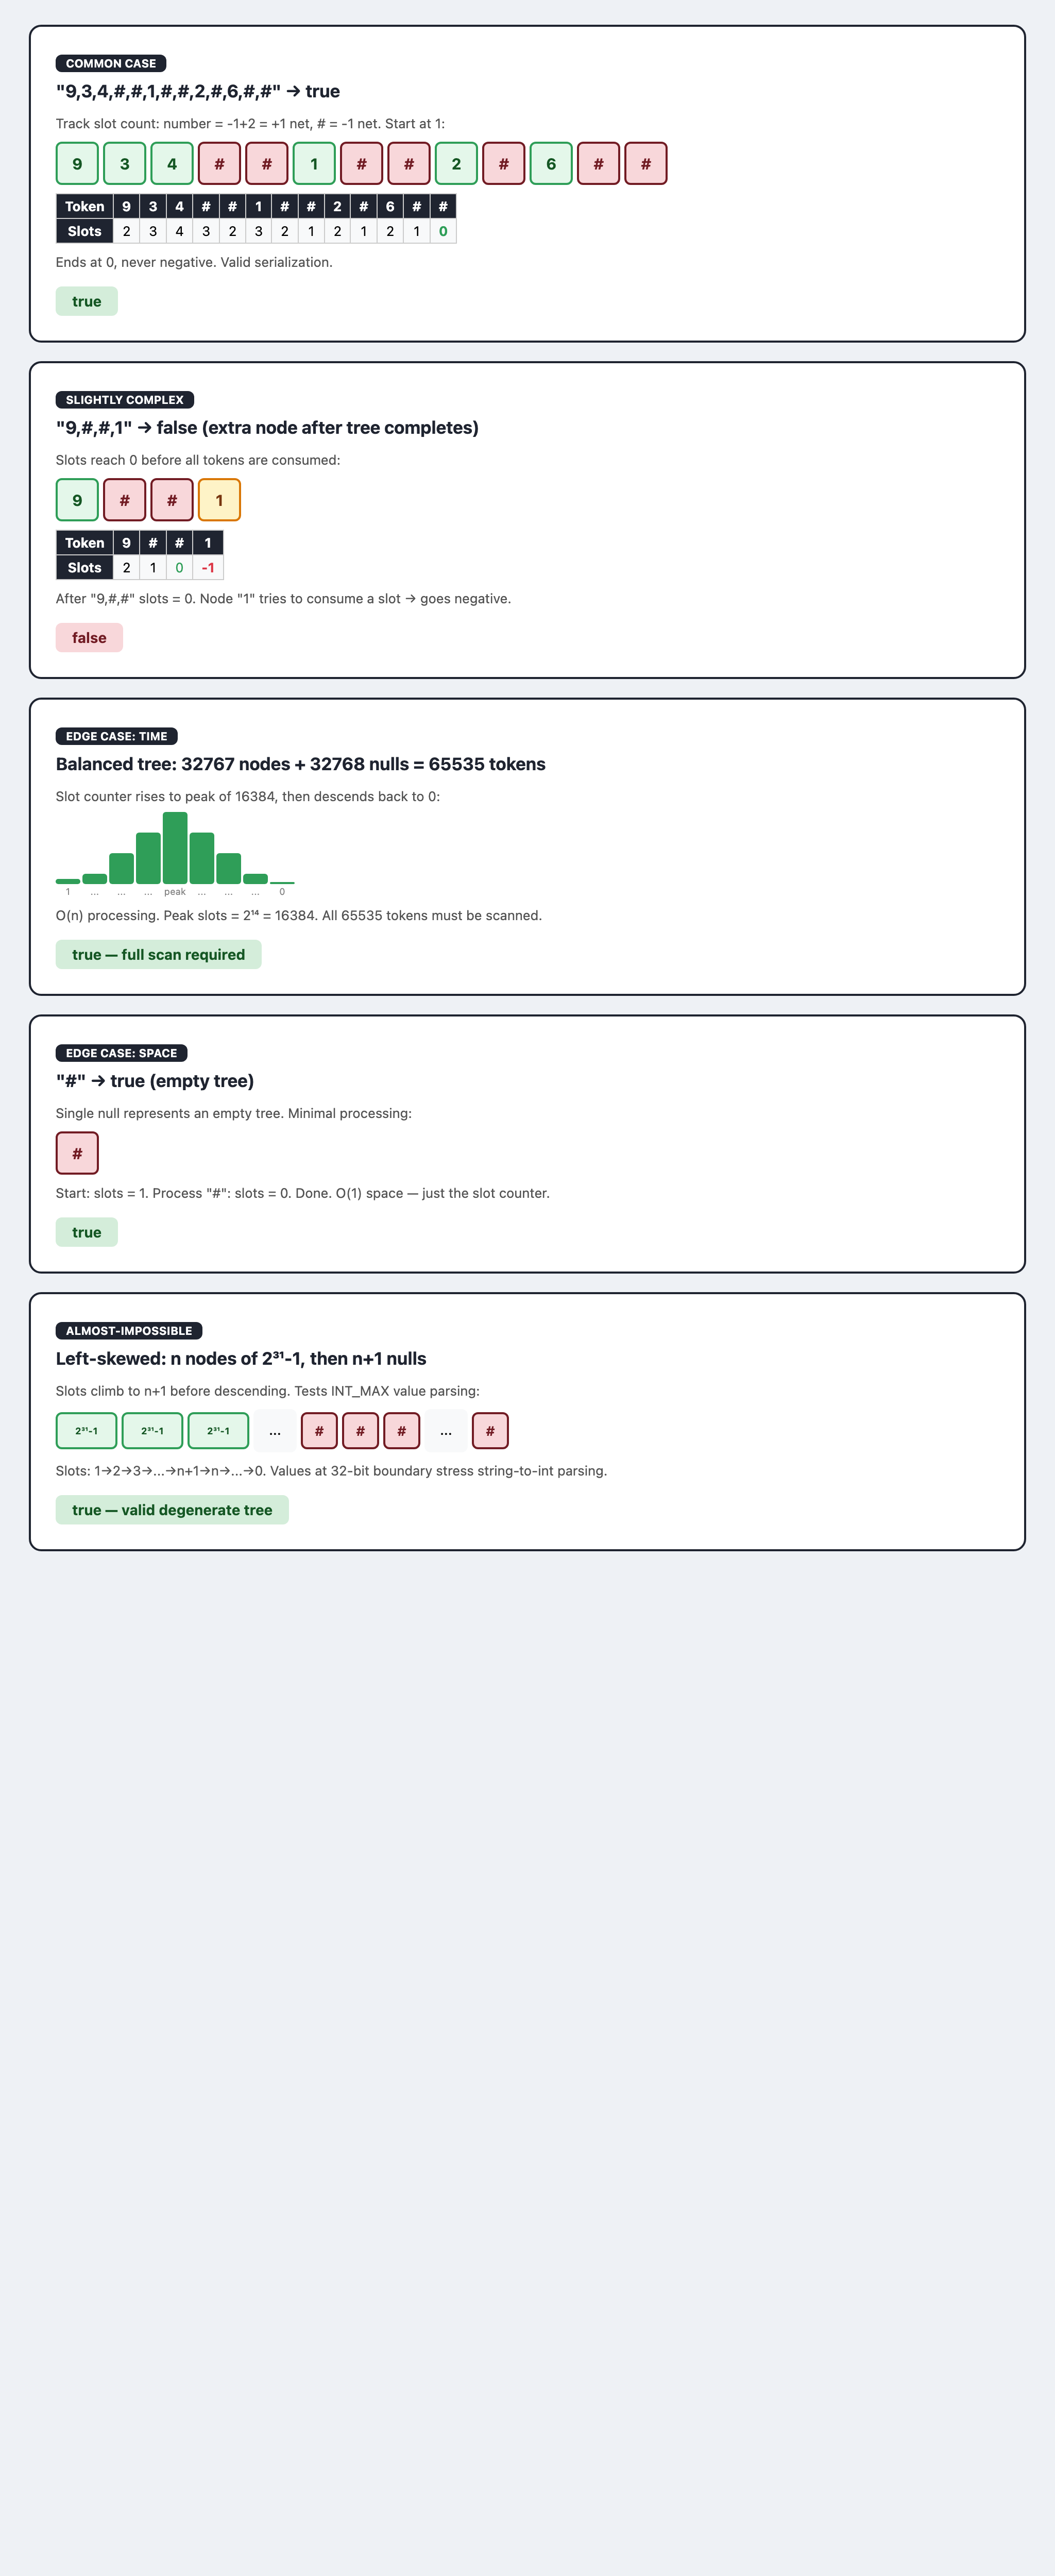